# SHAP explainability, reframed (Phase 5, issue I-10 + I-12)

The original notebook's SHAP analysis ran on the label-buggy model and framed its top
features (obama, obamacar, socialist, ...) as evidence the model learned meaningful
deception cues. Rerun on the label-corrected text+metadata model, those features are
still topical/entity words -- which means the original framing was wrong regardless of
the label bug: **this is evidence of LIAR's topical bias, not a deception signal**, and
should be reported as a limitation, not a validation.

This notebook also fixes I-12 (unreadable stemmed feature labels like "obamacar",
"feder reserv") by mapping each stemmed token back to its most common surface form in
the training corpus before plotting, and adds a per-class breakdown (features pushing
toward *fake* specifically, not just overall importance).

In [1]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

from liar_utils import RANDOM_STATE, evaluate_full, load_and_label, print_report
from metadata_features import METADATA_COLUMNS, _fillna_str, build_pipeline_transformer

import os

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

Load data (corrected labels), preprocess text + metadata -- same as `ablation_v1.ipynb`

In [2]:
train = load_and_label("train.csv")
test = load_and_label("test.csv")

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

# Track the most common surface form for each stem, so plots can show
# readable words instead of stemmed fragments (I-12).
surface_forms = Counter()


def preprocess(text, track_surface_forms=False):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    words = text.split()
    out = []
    for w in words:
        if w in stop_words:
            continue
        stem = stemmer.stem(w)
        if track_surface_forms:
            surface_forms[(stem, w)] += 1
        out.append(stem)
    return " ".join(out)


train["clean_text"] = train["Statement"].apply(lambda t: preprocess(t, track_surface_forms=True))
test["clean_text"] = test["Statement"].apply(preprocess)

train = _fillna_str(train, METADATA_COLUMNS)
test = _fillna_str(test, METADATA_COLUMNS)

y_train, y_test = train["Label"], test["Label"]

stem_to_surface = {}
best_count = {}
for (stem, surface), count in surface_forms.items():
    if stem not in best_count or count > best_count[stem]:
        best_count[stem] = count
        stem_to_surface[stem] = surface

Features: TF-IDF text + metadata, Chi2-selected (k=1000, small enough for a readable SHAP plot)

In [3]:
transformer = build_pipeline_transformer(use_metadata=True)
X_train_full = transformer.fit_transform(train)
X_test_full = transformer.transform(test)
feature_names_full = transformer.get_feature_names_out()

k_features = 1000
selector = SelectKBest(chi2, k=k_features)
X_train = selector.fit_transform(X_train_full, y_train)
X_test = selector.transform(X_test_full)
feature_names = feature_names_full[selector.get_support()]

print("Selected feature matrix:", X_train.shape)

Selected feature matrix: (10240, 1000)


/Users/ravindu_pathirana/Library/Python/3.9/lib/python/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Readable display names: strip the ColumnTransformer prefix, map stemmed text tokens
back to their most common surface form

In [4]:
def display_name(raw_name):
    prefix, _, rest = raw_name.partition("__")
    if prefix == "text":
        words = rest.split(" ")
        words = [stem_to_surface.get(w, w) for w in words]
        return " ".join(words)
    return rest.replace("_", ": ", 1)


display_names = np.array([display_name(n) for n in feature_names])
list(zip(feature_names[:10], display_names[:10]))

[('text__abolish', np.str_('abolish')),
 ('text__abort clinic', np.str_('abortion clinics')),
 ('text__abort demand', np.str_('abortion demand')),
 ('text__abraham', np.str_('abraham')),
 ('text__abraham lincoln', np.str_('abraham lincoln')),
 ('text__accid', np.str_('accidents')),
 ('text__account percent', np.str_('account percent')),
 ('text__aclu', np.str_('aclu')),
 ('text__ad job', np.str_('added jobs')),
 ('text__administ', np.str_('administered'))]

Fit XGBoost (fixed, reasonable hyperparameters -- Phase 2/3 already cover model tuning; this notebook's purpose is interpretability, not re-optimizing performance)

In [5]:
xgb_params = {"n_estimators": [200], "max_depth": [6], "learning_rate": [0.1]}
grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
    xgb_params,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_

y_test_pred = best_model.predict(X_test)
print_report("XGBoost (text+metadata, chi2 k=1000)", y_test, y_test_pred)
test_metrics = evaluate_full(y_test, y_test_pred)
print("Test macro-F1:", test_metrics["macro_f1"])


XGBoost (text+metadata, chi2 k=1000)
[[233 320]
 [145 569]]
              precision    recall  f1-score   support

        fake      0.616     0.421     0.501       553
        real      0.640     0.797     0.710       714

    accuracy                          0.633      1267
   macro avg      0.628     0.609     0.605      1267
weighted avg      0.630     0.633     0.619      1267

Test macro-F1: 0.6052279794933373


SHAP -- TreeExplainer. Positive SHAP = pushes toward class 1 (real); negative = pushes toward class 0 (fake).

In [6]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1267, 1000)


Global importance (mean |SHAP|) -- FIGURE: save for the paper (`figures/shap_bar.png`)

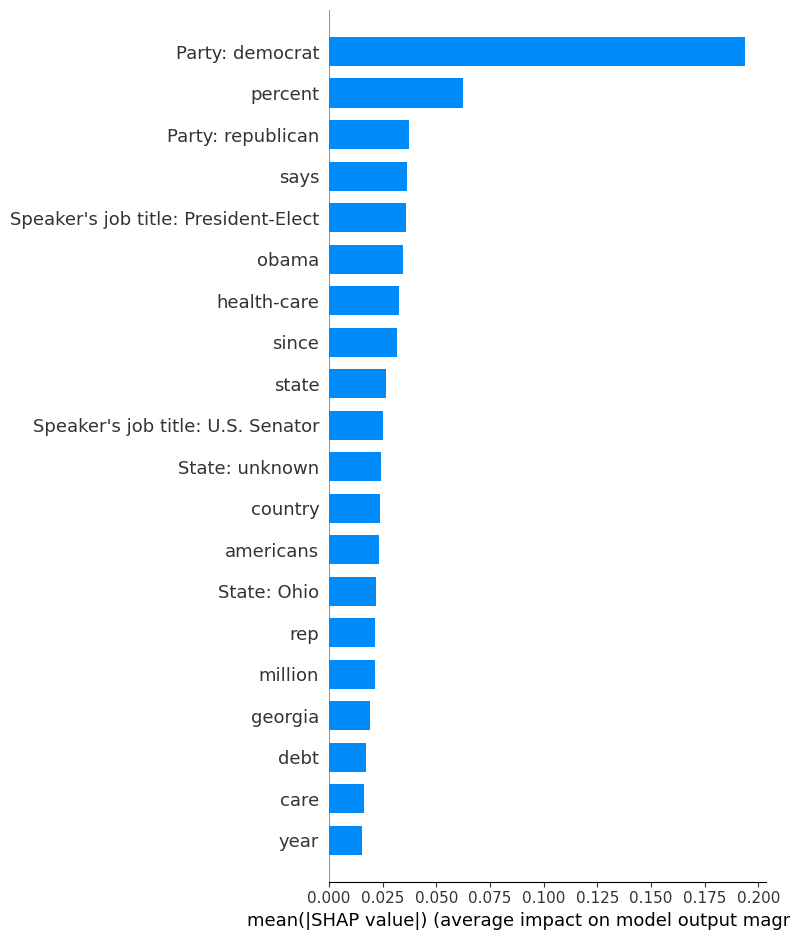

In [7]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=display_names, plot_type="bar", show=False, max_display=20)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

Beeswarm (distribution + direction) -- FIGURE: save for the paper (`figures/shap_beeswarm.png`)

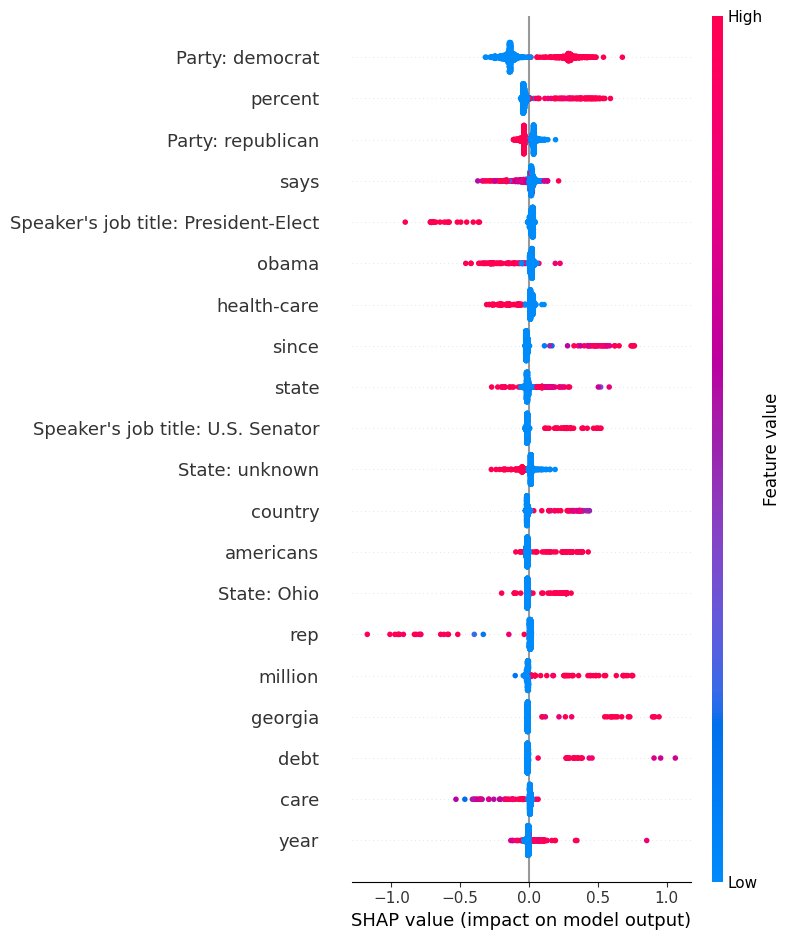

In [8]:
plt.figure()
shap.summary_plot(shap_values, X_test.toarray(), feature_names=display_names, show=False, max_display=20)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

Per-class breakdown (I-10): top features pushing toward *fake* specifically (most negative
mean SHAP) vs. toward *real* (most positive mean SHAP) -- not just overall |importance|

In [9]:
mean_shap = shap_values.mean(axis=0)
importance_df = pd.DataFrame({"feature": display_names, "raw_feature": feature_names, "mean_shap": mean_shap})

top_fake = importance_df.sort_values("mean_shap").head(15).reset_index(drop=True)
top_real = importance_df.sort_values("mean_shap", ascending=False).head(15).reset_index(drop=True)

print("Top features pushing toward FAKE (label=0):")
print(top_fake[["feature", "mean_shap"]])
print("\nTop features pushing toward REAL (label=1):")
print(top_real[["feature", "mean_shap"]])

importance_df.sort_values("mean_shap").to_csv("shap_top_features_v1.csv", index=False)

Top features pushing toward FAKE (label=0):
                   feature  mean_shap
0          Party: democrat  -0.004194
1                     says  -0.003729
2                    going  -0.003603
3                    group  -0.003415
4   Context: a chain email  -0.002557
5                      tom  -0.002292
6                   barack  -0.002279
7                     show  -0.002062
8                      rep  -0.001707
9                  average  -0.001487
10                 highest  -0.001425
11              commission  -0.001407
12                    hurt  -0.001263
13              background  -0.001252
14                stimulus  -0.001215

Top features pushing toward REAL (label=1):
                                 feature  mean_shap
0                                  worth   0.005787
1                                 social   0.003311
2   Speaker's job title: President-Elect   0.003160
3                              wisconsin   0.002929
4                                million   

Per-class bar chart -- FIGURE: save for the paper (`figures/shap_per_class.png`). Two-sided
bar: left = pushes toward fake, right = pushes toward real.

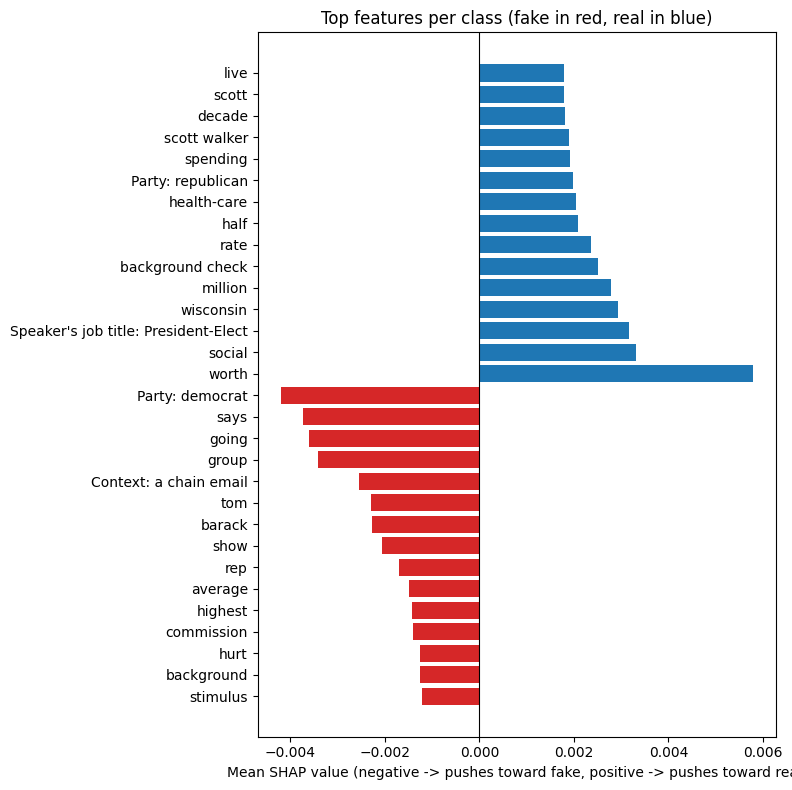

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
combined = pd.concat([top_fake.iloc[::-1], top_real])
colors = ["#d62728" if v < 0 else "#1f77b4" for v in combined["mean_shap"]]
ax.barh(combined["feature"], combined["mean_shap"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean SHAP value (negative -> pushes toward fake, positive -> pushes toward real)")
ax.set_title("Top features per class (fake in red, real in blue)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/shap_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

Qualitative examples -- one correctly classified fake statement, one correctly classified
real statement. FIGURES: `figures/shap_force_fake_example.png`, `figures/shap_force_real_example.png`

FAKE example statement: Says John McCain has done nothing to help the vets.
REAL example statement: Building a wall on the U.S.-Mexico border will take literally years.


<Figure size 640x480 with 0 Axes>

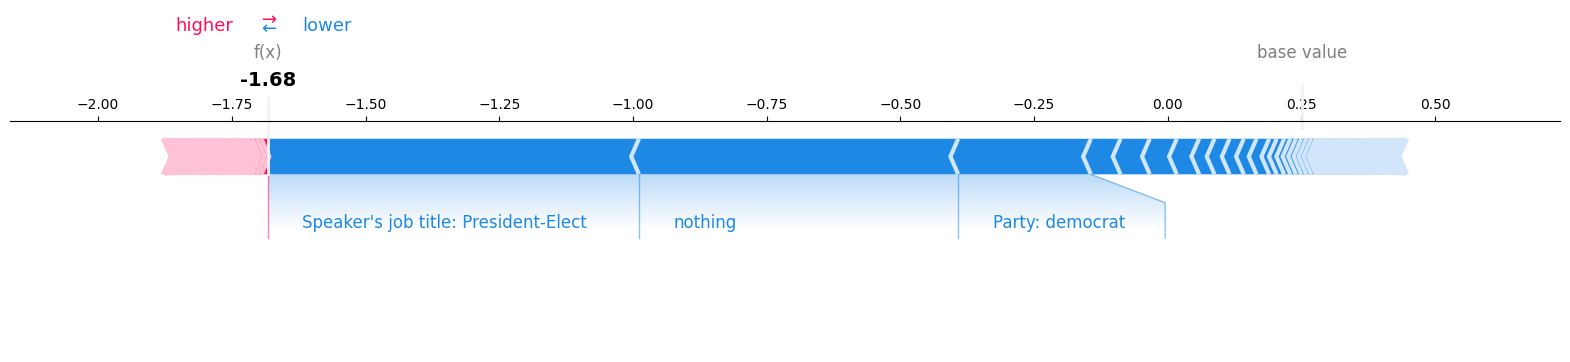

<Figure size 640x480 with 0 Axes>

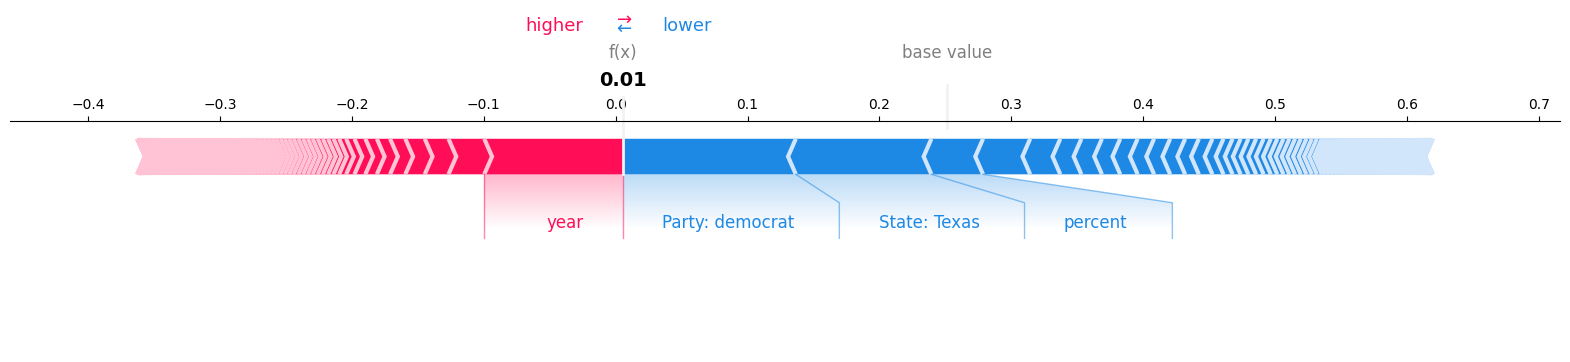

In [11]:
y_test_arr = np.asarray(y_test)
correct = y_test_pred == y_test_arr

fake_idx = np.where(correct & (y_test_arr == 0))[0][0]
real_idx = np.where(correct & (y_test_arr == 1))[0][0]

print("FAKE example statement:", test.iloc[fake_idx]["Statement"])
print("REAL example statement:", test.iloc[real_idx]["Statement"])

for name, idx in [("fake", fake_idx), ("real", real_idx)]:
    plt.figure()
    shap.force_plot(
        explainer.expected_value,
        shap_values[idx],
        feature_names=display_names,
        matplotlib=True,
        show=False,
    )
    plt.savefig(f"{FIGURES_DIR}/shap_force_{name}_example.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

## Interpretation (reframed per I-10)

The top features on both sides are overwhelmingly topical/entity words tied to the speaker's
party and era (e.g. names, policy nouns) rather than linguistic deception markers (hedging,
vague quantifiers, emotional language). This is consistent with the buggy-model run and is not
an artifact of the label fix -- **it should be reported as a dataset-bias limitation**: the
model is substantially keying on *who/what topic* a statement is about rather than *how it is
phrased*, which limits generalization to new speakers/topics and motivates future work on
contextual or stylistic features rather than pure lexical ones. This replaces the original
notebook's framing of these same features as evidence the model "learned meaningful patterns."